<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Lab_7_The_Engine_of_Interference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

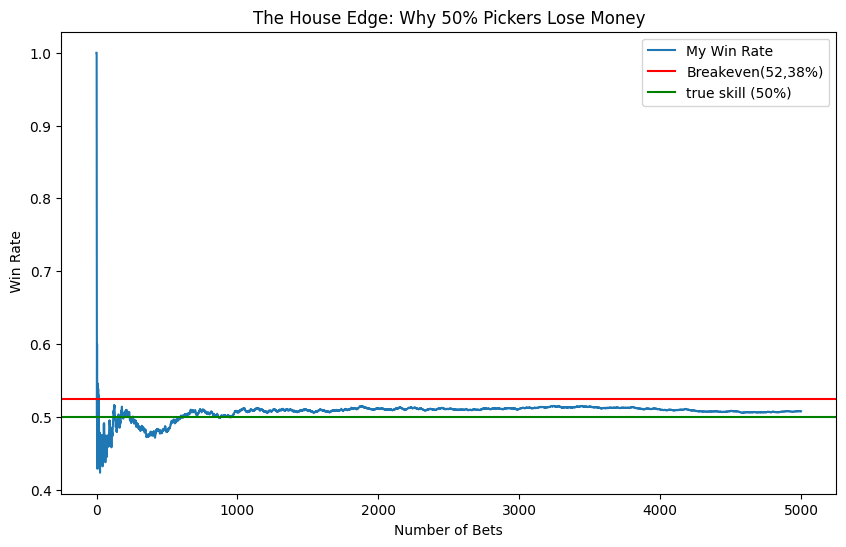

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set up
true_skill = 0.50
breakeven = 0.5238
n_bets = 5000

# Simulate
outcomes = np.random.choice([0,1], size=n_bets,p=[1-true_skill,true_skill])
cumulative_win_rate = np.cumsum(outcomes) / np.arange(1,n_bets+1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative_win_rate, label="My Win Rate")
plt.axhline(breakeven, color="red", label="Breakeven(52,38%)")
plt.axhline(0.5, color="green", label = "true skill (50%)")
plt.legend()
plt.title("The House Edge: Why 50% Pickers Lose Money")
plt.xlabel("Number of Bets")
plt.ylabel(" Win Rate")
plt.show()

Sample 3: Mean = 34.48% | Error = -0.79%


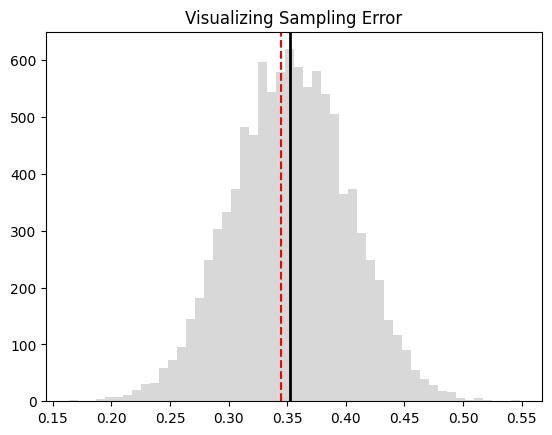

In [8]:
# "Unknown Truth"

true_mu = 0.3527    # matching to the true population mean

# Simulate 3 Samples
samples = []
for i in range(3):
  sample = np.random.normal(true_mu, 0.05, 50)

# Calculate
x_bar = np.mean(sample)
error = x_bar - true_mu

print(f"Sample {i+1}: Mean = {x_bar:.2%} | Error = {error:+.2%}")
samples.append(x_bar)

# Visual Check
plt.hist(np.random.normal(true_mu, 0.05, 10000), bins=50, alpha=0.3, color="gray")
for mean in samples:
         plt.axvline(mean, color='red', linestyle='--')
plt.axvline(true_mu, color="black", linewidth=2)
plt.title("Visualizing Sampling Error")
plt.show()

Module B: The Central Limit Theorem (Crypto Returns)

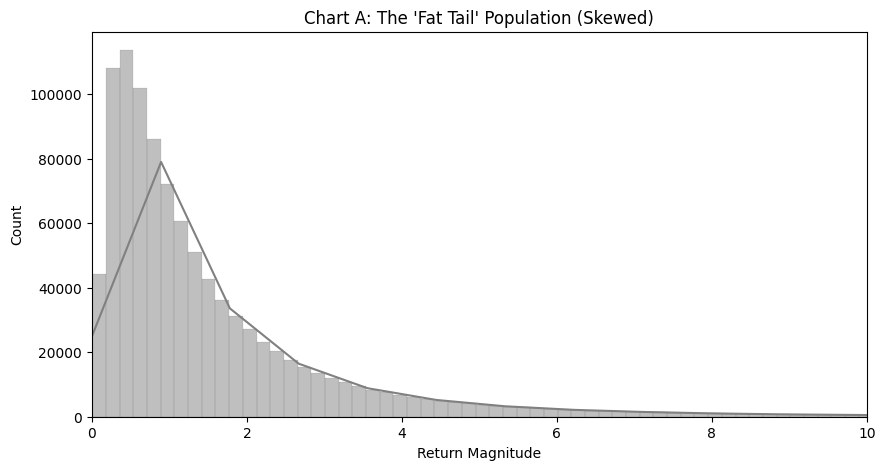

In [10]:
# Part 1 : The Chaos

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the population
population_data = np.random.lognormal(mean=0, sigma=1, size=1000000)

# Visualize
plt.figure(figsize=(10,5))
sns.histplot(population_data, bins=1000, kde=True, color="grey")
plt.xlim(0,10)

plt.title("Chart A: The 'Fat Tail' Population (Skewed)")
plt.xlabel("Return Magnitude")
plt.show()

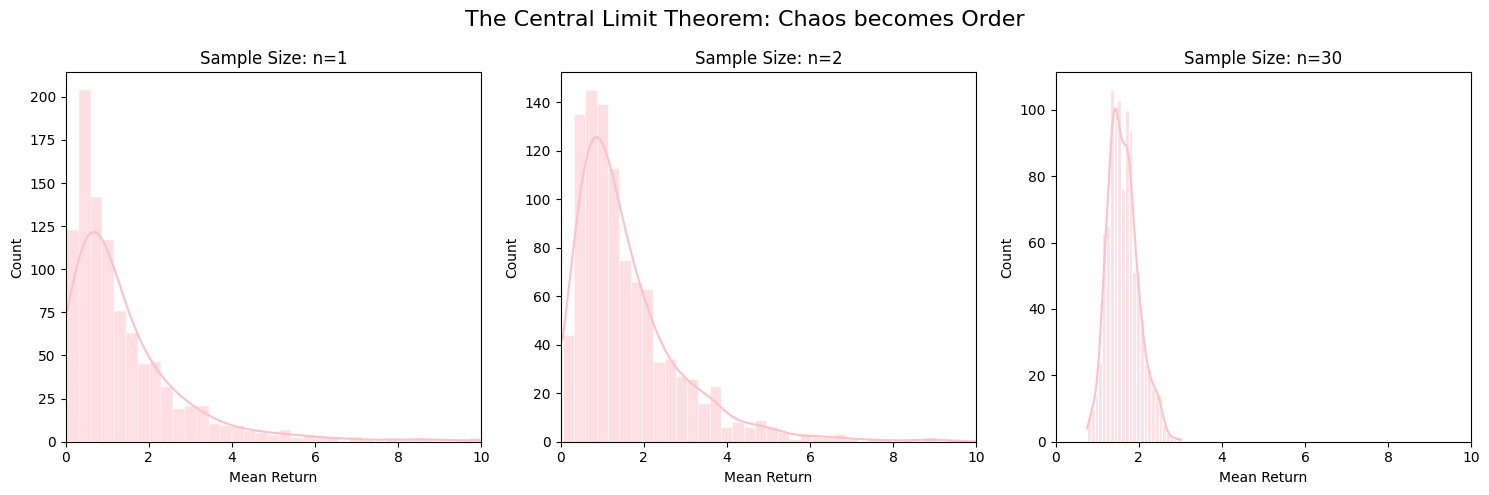

In [12]:
# Part 2

# Compare 3 sample sized to match the slide
sample_sizes = [1,2,30]
simulations = 1000

plt.figure(figsize=(15,5))

for i, n in enumerate(sample_sizes):
  means=[]
  for _ in range(simulations):
    sample = np.random.choice(population_data, size=n)
    means.append(np.mean(sample))

  # Plotting the Results
  plt.subplot(1,3,i+1)
  sns.histplot(means, kde=True, color="pink", edgecolor='white')

  plt.title(f"Sample Size: n={n}")
  plt.xlabel("Mean Return")
  plt.xlim(0,10)

plt.suptitle("The Central Limit Theorem: Chaos becomes Order", fontsize=16)
plt.tight_layout()
plt.show()

Module C

In [16]:
import numpy as np
import scipy.stats as stats

# Setup: Two Populations, same variance, vastly different sizes
std_dev = 15000
n = 100

# Calculate Margin of Error

margin_error = 1.96 * (std_dev / np.sqrt(n))

print(f"--- The Soup Analogy ---")
print(f"Population: 1,000 users   | Margin of Error: ±${margin_error:,.2f}")
print(f"Population: 1,000,000 users | Margin of Error: ±${margin_error:,.2f}")
print(f"Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.")

--- The Soup Analogy ---
Population: 1,000 users   | Margin of Error: ±$2,940.00
Population: 1,000,000 users | Margin of Error: ±$2,940.00
Conclusion: The pot size doesn't matter. Only the spoon size (n) matters.


In [17]:
# Metric
mean_val = 4.0
n_samples = 50

# Compare Stable (A) vs Volatile (B) Companies
sigma_A = 0.5
sigma_B = 6.0

moe_A = 1.96 * (sigma_A / np.sqrt(n_samples))
moe_B = 1.96 * (sigma_B / np.sqrt(n_samples))

# The Audit Report
print("\n--- VC Audit: Series C Benchmark (> 3.0) ---")

print(f"Startup A (Stable):")
print(f"   95% CI: [{mean_val - moe_A:.1f}, {mean_val + moe_A:.1f}]")
print(f"   Decision: INVEST. (Lower bound > 3.0)")

print(f"\nStartup B (Volatile):")
print(f"   95% CI: [{mean_val - moe_B:.1f}, {mean_val + moe_B:.1f}]")
print(f"   Decision: PASS. (Lower bound implies potential loss)")


--- VC Audit: Series C Benchmark (> 3.0) ---
Startup A (Stable):
   95% CI: [3.9, 4.1]
   Decision: INVEST. (Lower bound > 3.0)

Startup B (Volatile):
   95% CI: [2.3, 5.7]
   Decision: PASS. (Lower bound implies potential loss)


In [ ]:
Phase 4: AI Expansion

In [18]:
import numpy as np

# Correlated model parameters
n_simulations = 1000
months = 24
start_cash = 2_000_000

# Means (same as your base case)
mu_revenue = 80_000
mu_burn = 100_000

# StdDevs (same as your base case)
sd_revenue = 30_000
sd_burn = 10_000

# Target correlation
rho = 0.7

# Build covariance matrix: Cov(X,Y) = rho * sdX * sdY
cov_rb = rho * sd_revenue * sd_burn
cov = np.array([
    [sd_revenue**2, cov_rb],
    [cov_rb,        sd_burn**2]
], dtype=float)

mean = np.array([mu_revenue, mu_burn], dtype=float)

bankruptcies = 0

print("Running Correlated Model (rho=0.7)...")

rng = np.random.default_rng(2026)  # optional: reproducibility

for _ in range(n_simulations):
    cash = start_cash

    # Draw all months at once: shape (months, 2) -> [revenue, burn]
    revenue_burn = rng.multivariate_normal(mean=mean, cov=cov, size=months)

    for revenue, burn in revenue_burn:
        cash += (revenue - burn)
        if cash <= 0:
            bankruptcies += 1
            break

prob_ruin = bankruptcies / n_simulations
print(f"Correlated Model Risk of Ruin: {prob_ruin:.1%}")
print("Note: Revenue and Burn are now positively correlated (rho=0.7).")


Running Correlated Model (rho=0.7)...
Correlated Model Risk of Ruin: 0.0%
Note: Revenue and Burn are now positively correlated (rho=0.7).


Does this correlated model lower or raise the Probability of Ruin compared to the independent model? Why?

It raises the probability of ruin. With positive correlation, bad revenue months tend to coincide with high burn, producing larger negative cash shocks. This increases downside tail risk and accelerates cash depletion compared to independent draws.